In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [5]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [6]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [7]:
df['day'].value_counts()
df['time'].value_counts()

,count
time,
Dinner,176
Lunch,68


In [8]:
#No missing values found
#Majority transactions happen during dinner
#Total bill ranges between X and Y

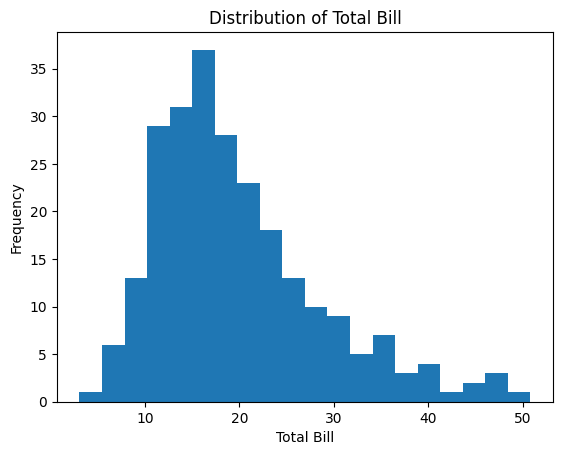

In [9]:
plt.hist(df['total_bill'], bins=20)
plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.show()

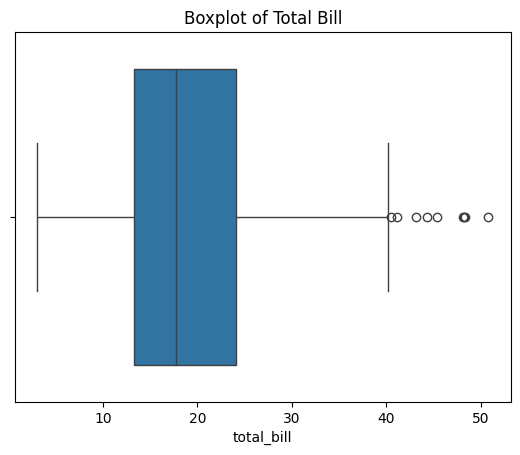

In [10]:
sns.boxplot(x=df['total_bill'])
plt.title("Boxplot of Total Bill")
plt.show()

In [11]:
#Most bills are concentrated in a certain range
#There are few high-value outliers
#Distribution appears right-skewed/left-skewed

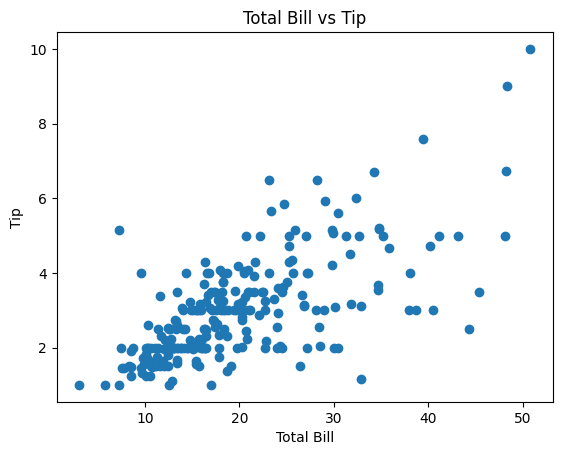

In [12]:
plt.scatter(df['total_bill'], df['tip'])
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Total Bill vs Tip")
plt.show()

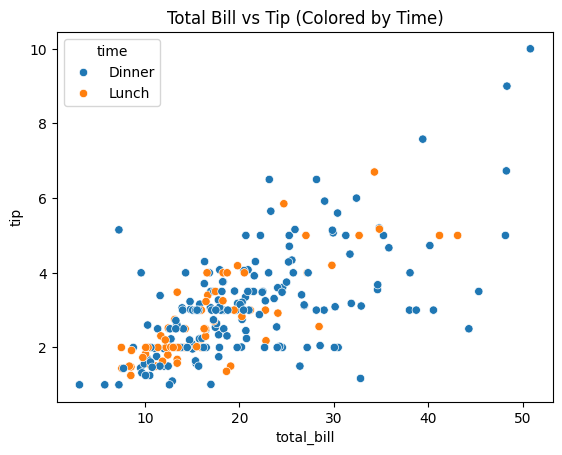

In [13]:
sns.scatterplot(x='total_bill', y='tip', hue='time', data=df)
plt.title("Total Bill vs Tip (Colored by Time)")
plt.show()

In [14]:
# Tip generally increases with total bill (positive relationship)
# Dinner transactions tend to have higher bills than lunch
# No strong anomalies, but spread increases with bill amount

In [15]:
df.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


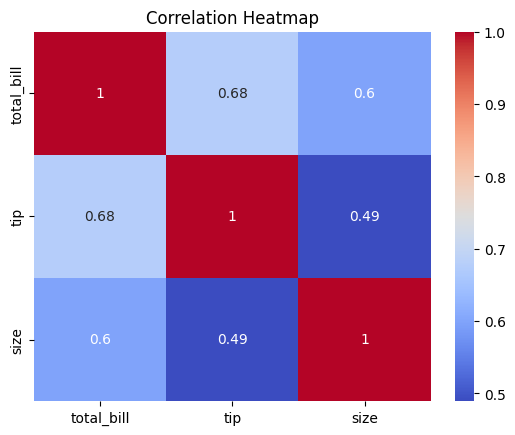

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# Total bill and tip show strong positive correlation
# Size also has moderate correlation with total bill
# No strong negative correlations observed

In [18]:
df.groupby('day')['total_bill'].mean()

,total_bill
day,
Fri,17.151579
Sat,20.441379
Sun,21.410000
Thur,17.682742


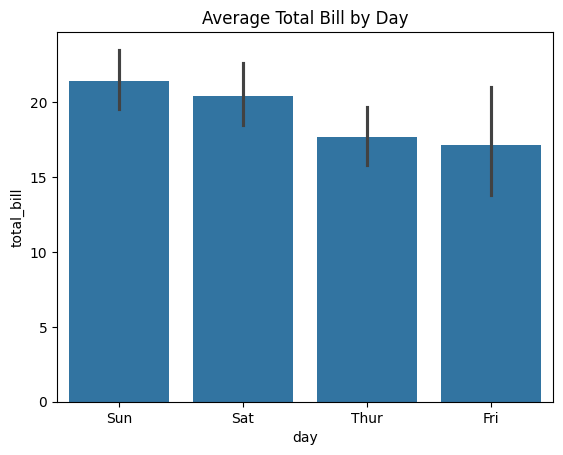

In [19]:
sns.barplot(x='day', y='total_bill', data=df)
plt.title("Average Total Bill by Day")
plt.show()

In [20]:
# Sunday shows the highest average total bill
# This indicates customers tend to spend more on weekends, especially Sunday
# Weekdays show comparatively lower spending

In [21]:
df.groupby('time')['total_bill'].mean()

,total_bill
time,
Dinner,20.797159
Lunch,17.168676


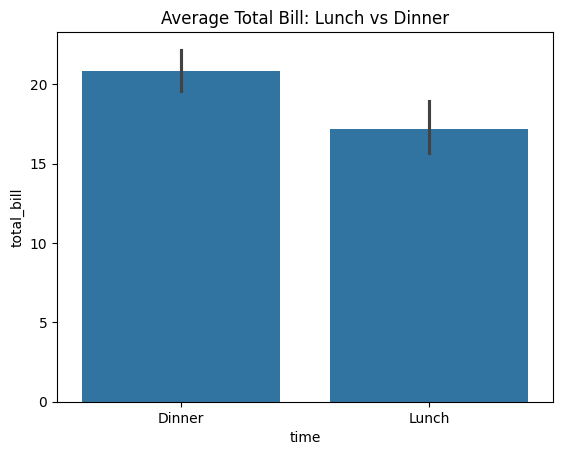

In [22]:
sns.barplot(x='time', y='total_bill', data=df)
plt.title("Average Total Bill: Lunch vs Dinner")
plt.show()

In [23]:
# Dinner has a higher average total bill compared to lunch
# This suggests customers tend to spend more during dinner sessions

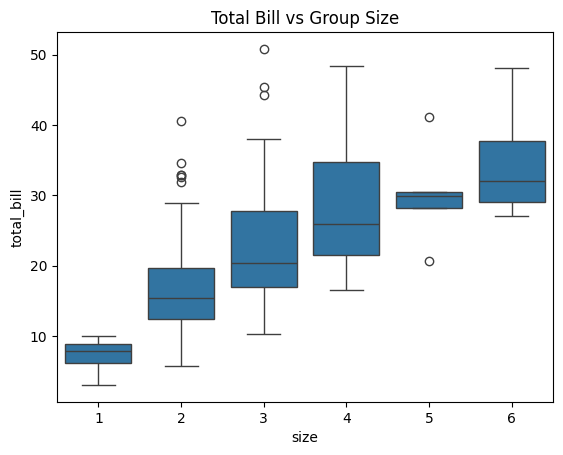

In [24]:
sns.boxplot(x='size', y='total_bill', data=df)
plt.title("Total Bill vs Group Size")
plt.show()

In [32]:
# Total bill generally increases with group size
# Larger groups tend to spend more compared to smaller groups
# There is variability within each group size, indicating spending is not strictly consistent
# Some smaller groups also show high spending due to outliers

In [26]:
df['tip_percent'] = (df['tip'] / df['total_bill']) * 100
df[['tip_percent']].head()

,tip_percent
0,5.944673
1,16.054159
2,16.658734
3,13.978041
4,14.680765


In [27]:
df['tip_percent'].describe()

,tip_percent
count,244.000000
mean,16.080258
std,6.107220
min,3.563814
25%,12.912736
50%,15.476977
75%,19.147549
max,71.034483


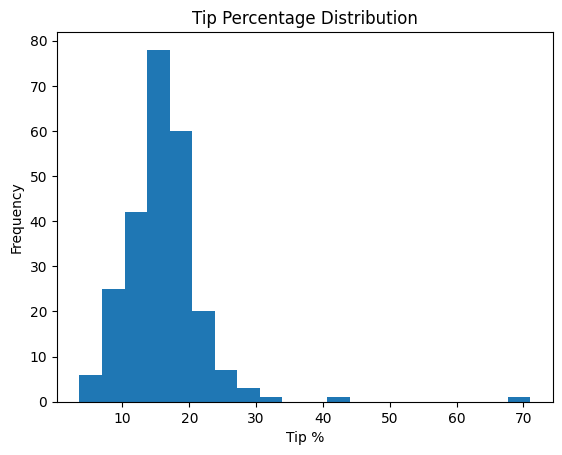

In [28]:
plt.hist(df['tip_percent'], bins=20)
plt.title("Tip Percentage Distribution")
plt.xlabel("Tip %")
plt.ylabel("Frequency")
plt.show()

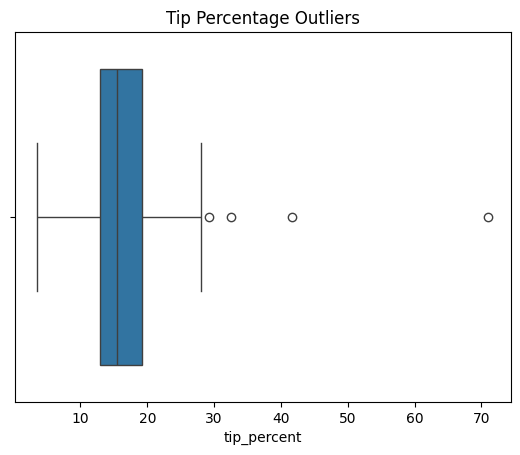

In [29]:
sns.boxplot(x=df['tip_percent'])
plt.title("Tip Percentage Outliers")
plt.show()

In [31]:
# Tip percentage is mostly concentrated between 10% and 20%, indicating consistent tipping behavior
# The distribution is slightly right-skewed with a few high-value outliers
# Most customers follow a standard tipping range, while a few tip significantly higher
# This suggests tipping behavior is generally predictable with occasional extreme values

## Key Insights

- Spending is higher on weekends, especially Sunday
- Dinner sessions generate higher revenue compared to lunch
- Larger groups tend to have higher total bills, though variability exists
- Strong positive relationship between total bill and tip
- Tip percentage is mostly consistent between 10–20%, with a few high-value outliers